<a href="https://colab.research.google.com/github/HilmanAlDwinov/Tugas_Akhir_FSD_Supervised_Unsupervised_Learning/blob/main/FSD_Kelompok_Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project Fundamental Sains Data

# Prediksi Penyakit Jantung Menggunakan Supervised Learning dan Analisis Klaster Pasien Menggunakan Unsupervised Learning

---

## Anggota Kelompok

- Hilman Al Dwinov (24523216)
- Ibrahim Ivanka (24523279)


---

# Dataset

**Nama Dataset**

Heart Disease Prediction Dataset

**Sumber Dataset (Kaggle)**

https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

Dataset ini merupakan dataset klasifikasi penyakit jantung yang berisi informasi kondisi kesehatan pasien seperti usia, jenis kelamin, tekanan darah, kadar kolesterol, denyut jantung maksimum, serta beberapa indikator medis lainnya. Dataset ini banyak digunakan sebagai benchmark dalam penelitian maupun implementasi Machine Learning untuk klasifikasi penyakit jantung.

---

# Deskripsi Proyek

Penyakit jantung merupakan salah satu penyebab kematian tertinggi di dunia. Oleh karena itu, diperlukan suatu metode yang mampu membantu proses identifikasi risiko penyakit jantung secara lebih cepat dan akurat. Salah satu pendekatan yang dapat digunakan adalah Machine Learning, yang mampu mempelajari pola dari data historis untuk menghasilkan prediksi maupun menemukan pola tersembunyi pada data.

Pada proyek ini digunakan **Heart Disease Prediction Dataset** sebagai sumber data utama untuk mengimplementasikan dua pendekatan Machine Learning, yaitu **Supervised Learning** dan **Unsupervised Learning**. Penggunaan satu dataset yang sama bertujuan agar hasil prediksi dan hasil clustering dapat saling melengkapi sehingga memberikan pemahaman yang lebih komprehensif terhadap karakteristik pasien.

Pendekatan **Supervised Learning** digunakan untuk membangun model klasifikasi yang mampu memprediksi apakah seorang pasien berpotensi mengalami penyakit jantung berdasarkan kondisi kesehatannya.

Sementara itu, pendekatan **Unsupervised Learning** digunakan untuk mengelompokkan pasien berdasarkan kemiripan karakteristik kesehatan tanpa menggunakan informasi label penyakit. Hasil clustering diharapkan dapat membantu dalam mengenali kelompok pasien dengan karakteristik risiko yang berbeda.

---

# Tujuan Proyek

Proyek ini memiliki beberapa tujuan sebagai berikut.

1. Memahami karakteristik dataset melalui proses Exploratory Data Analysis (EDA).

2. Melakukan preprocessing data agar dataset siap digunakan dalam proses Machine Learning.

3. Membangun model Supervised Learning untuk memprediksi kemungkinan penyakit jantung pada pasien.

4. Mengevaluasi performa model klasifikasi menggunakan berbagai metrik evaluasi.

5. Melakukan clustering menggunakan algoritma K-Means untuk menemukan kelompok pasien berdasarkan karakteristik kesehatannya.

6. Menganalisis karakteristik setiap cluster sehingga diperoleh insight mengenai kondisi kesehatan pasien.

---

# Ruang Lingkup Analisis

# Tahapan Analisis

Notebook ini terdiri dari beberapa tahapan analisis sebagai berikut:

1.  Import Library
2.  Load Dataset
3.  Deskripsi Dataset
4.  Exploratory Data Analysis (EDA)
5.  Data Preprocessing
6.  Implementasi Supervised Learning
7.  Evaluasi Model
8.  Implementasi Unsupervised Learning
9.  Evaluasi Clustering
10. Pembuatan Antarmuka Prediksi Menggunakan Gradio
11. Insight dan Kesimpulan

#**1.Import Library**

Pada tahap ini dilakukan proses import library yang akan digunakan selama proses analisis data.

Library yang digunakan meliputi:

- **Pandas** untuk membaca dan memanipulasi dataset.
- **NumPy** untuk melakukan operasi numerik.
- **Matplotlib** dan **Seaborn** untuk membuat visualisasi data.
- **Warnings** untuk menyembunyikan pesan peringatan yang tidak memengaruhi proses analisis.

Library tambahan untuk Machine Learning akan diimport pada bagian implementasi model.

In [ ]:
# ==========================================
# Import Library
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Pengaturan tampilan
pd.set_option('display.max_columns', None)

print("Library berhasil diimport.")

Library berhasil diimport.


#**2.Load Dataset**

Dataset yang digunakan pada proyek ini adalah **Heart Disease Prediction Dataset**.

Dataset dibaca menggunakan library **Pandas** kemudian disimpan ke dalam variabel **df** agar dapat digunakan pada proses analisis selanjutnya.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart (2).csv


In [ ]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


#**3.Memahami Dataset**

##A.Dimensi Dataset

Tahap ini bertujuan untuk mengetahui ukuran dataset yang digunakan.

Informasi yang ditampilkan meliputi:

- Jumlah baris (observasi)
- Jumlah kolom (fitur)

In [ ]:
print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

Jumlah Baris : 1025
Jumlah Kolom : 14


##B.Informasi Dataset

Tahap ini digunakan untuk memahami struktur dataset.

Informasi yang diperoleh meliputi:

- Nama setiap fitur
- Jumlah data yang tersedia
- Tipe data masing-masing fitur
- Jumlah nilai non-null

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


##C.Statistik Deskriptif

Statistik deskriptif digunakan untuk mengetahui gambaran umum setiap fitur numerik.

Beberapa informasi yang ditampilkan antara lain:

- Mean
- Standar Deviasi
- Nilai Minimum
- Nilai Maksimum
- Kuartil (Q1, Median, Q3)

Informasi ini membantu memahami penyebaran data sebelum dilakukan preprocessing.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


##D.Menampilkan Lima Data Pertama

Lima data pertama ditampilkan untuk memahami bentuk dataset serta memastikan data berhasil dibaca dengan benar.

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


#E.Menampilkan Lima Data Terakhir

Selain melihat data awal, lima data terakhir juga ditampilkan untuk memastikan keseluruhan dataset telah terbaca dengan baik.

In [ ]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


# **4. Exploratory Data Analysis (EDA)**

##A.Pemeriksaan Missing Value

Missing value merupakan data yang kosong atau tidak memiliki nilai.

Keberadaan missing value dapat memengaruhi performa model Machine Learning sehingga perlu diperiksa sebelum dilakukan preprocessing.

In [ ]:
missing = df.isnull().sum()

missing

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


#### Interpretasi

Berdasarkan hasil pemeriksaan missing value, dapat diketahui apakah terdapat data yang kosong pada setiap fitur.

Apabila seluruh fitur memiliki nilai **0**, maka dataset tidak memiliki missing value sehingga tidak diperlukan proses imputasi data.

##B. Pemeriksaan Data Duplikat

Data duplikat merupakan data yang memiliki seluruh nilai atribut sama dengan data lainnya.

Data duplikat dapat menyebabkan bias pada model sehingga perlu diperiksa sebelum proses pelatihan model.

In [ ]:
duplicate = df.duplicated().sum()

print("Jumlah Data Duplikat :", duplicate)

Jumlah Data Duplikat : 723


##C.Distribusi Variabel Target

Visualisasi ini bertujuan untuk mengetahui jumlah pasien yang memiliki penyakit jantung dan yang tidak memiliki penyakit jantung.

Distribusi target yang seimbang akan membantu model klasifikasi menghasilkan performa yang lebih baik.

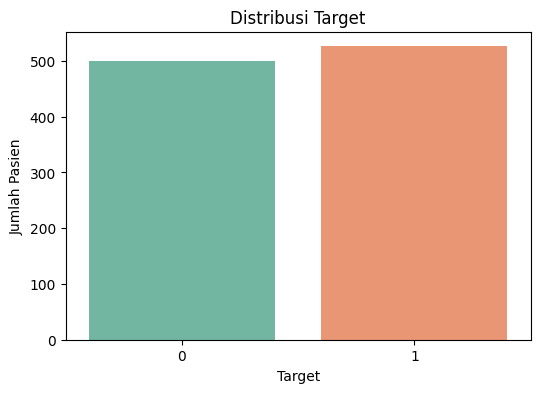

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x='target',
              palette='Set2')

plt.title("Distribusi Target")

plt.xlabel("Target")

plt.ylabel("Jumlah Pasien")

plt.show()

####Interpretasi

Grafik menunjukkan jumlah pasien yang termasuk ke dalam kelas **memiliki penyakit jantung (1)** dan **tidak memiliki penyakit jantung (0)**.

Distribusi target yang tidak terlalu timpang menunjukkan bahwa dataset cukup baik untuk digunakan pada proses klasifikasi.

##D.Distribusi Umur Pasien

Visualisasi histogram digunakan untuk mengetahui persebaran umur pasien pada dataset.

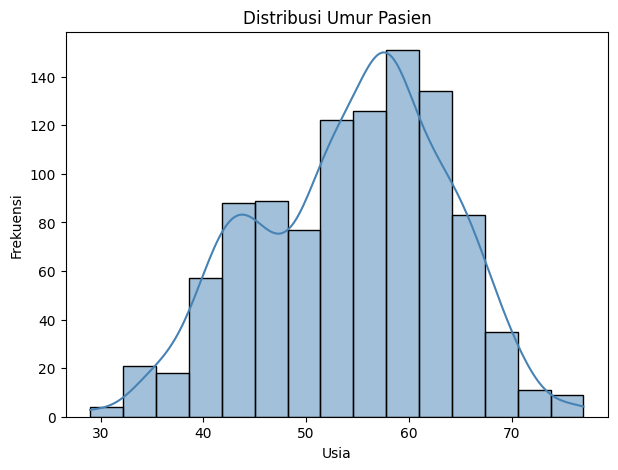

In [ ]:
plt.figure(figsize=(7,5))

sns.histplot(df['age'],
             bins=15,
             kde=True,
             color='steelblue')

plt.title("Distribusi Umur Pasien")

plt.xlabel("Usia")

plt.ylabel("Frekuensi")

plt.show()

#### Interpretasi

Histogram menunjukkan persebaran usia pasien pada dataset.

Dari visualisasi ini dapat diketahui rentang usia yang paling banyak muncul sehingga memberikan gambaran mengenai kelompok usia yang mendominasi dataset.

##E.Korelasi Antar Fitur

Heatmap digunakan untuk mengetahui hubungan antar variabel dalam dataset.

Semakin mendekati nilai **1**, maka hubungan antar variabel semakin kuat.

Semakin mendekati **-1**, maka hubungan negatif semakin kuat.

Nilai mendekati **0** menunjukkan hubungan yang lemah.

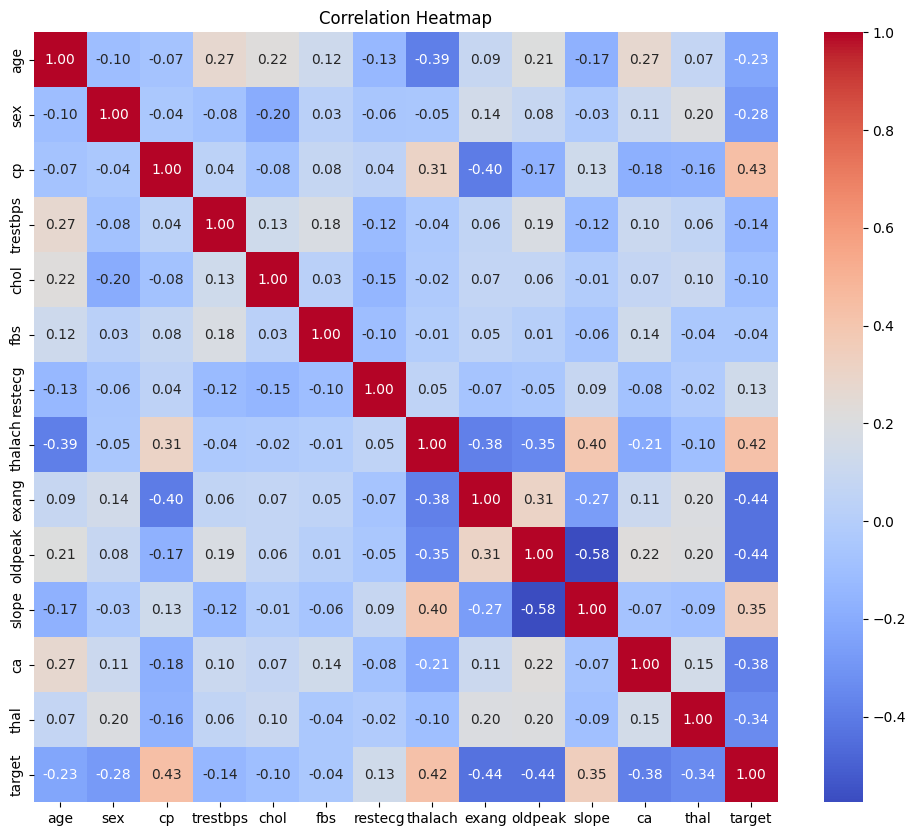

In [ ]:
plt.figure(figsize=(12,10))

corr = df.corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

####13.Interpretasi

Heatmap menunjukkan tingkat korelasi antar fitur pada dataset.

Fitur yang memiliki korelasi tinggi terhadap variabel **target** berpotensi menjadi faktor penting dalam proses prediksi penyakit jantung.

Selain itu, heatmap juga dapat digunakan untuk mengidentifikasi adanya multikolinearitas antar fitur.

##F.Distribusi Seluruh Variabel Numerik

Histogram digunakan untuk melihat distribusi seluruh variabel numerik secara bersamaan.

Visualisasi ini membantu memahami karakteristik setiap fitur sebelum dilakukan preprocessing.

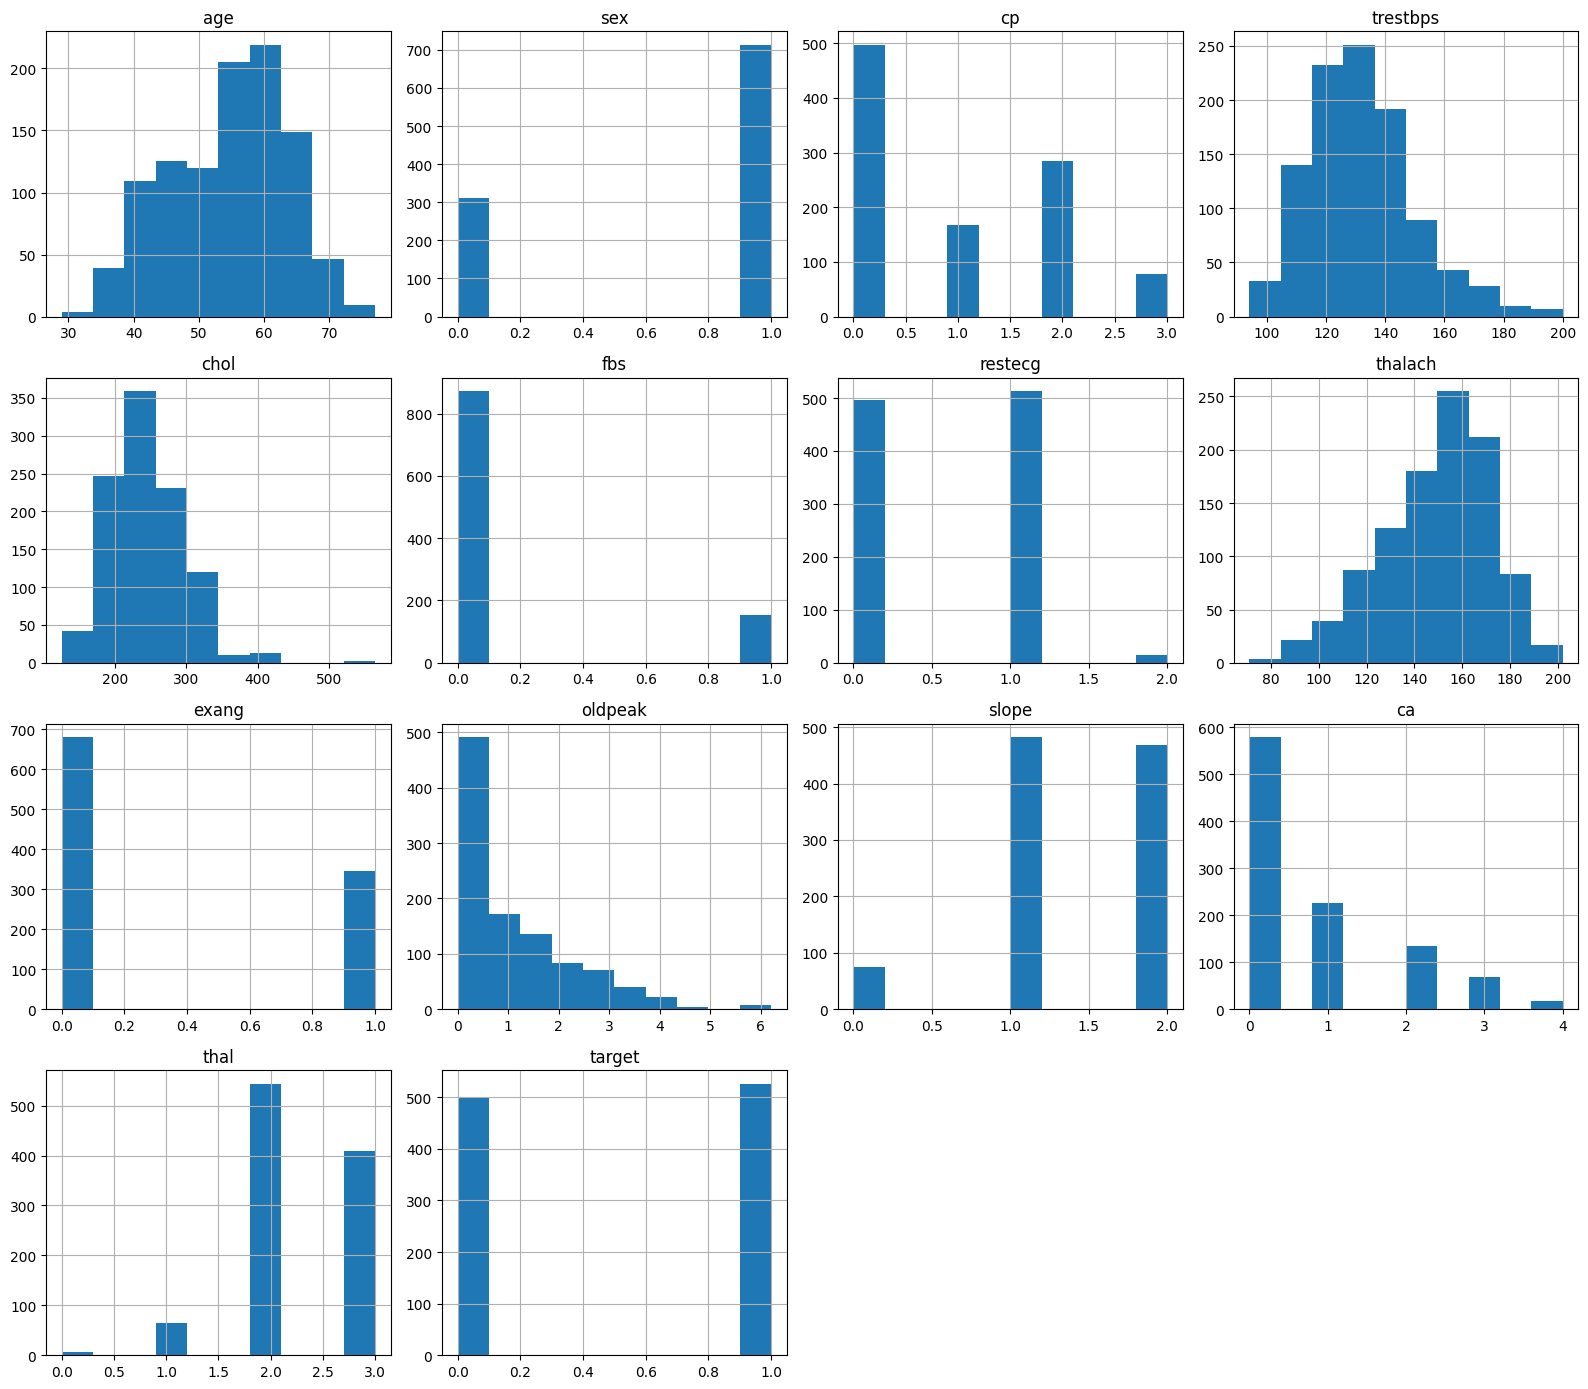

In [ ]:
df.hist(figsize=(16,14))

plt.tight_layout()

plt.show()

##H.Deteksi Outlier

Boxplot digunakan untuk mendeteksi keberadaan outlier pada setiap fitur numerik.

Outlier merupakan nilai yang berada jauh di luar rentang mayoritas data sehingga dapat memengaruhi performa model Machine Learning.

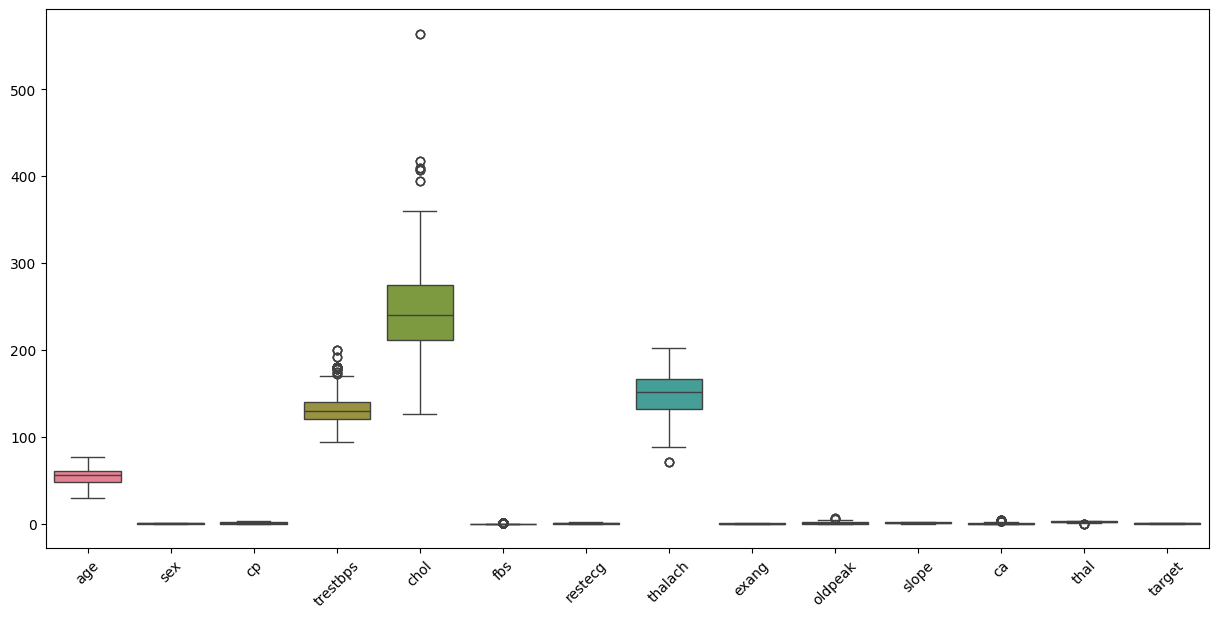

In [ ]:
plt.figure(figsize=(15,7))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.show()

####Interpretasi

Berdasarkan boxplot dapat diketahui fitur mana saja yang memiliki outlier.

Informasi ini akan digunakan sebagai dasar dalam menentukan metode penanganan outlier pada tahap preprocessing.

##I.Insight Hasil Exploratory Data Analysis

Berdasarkan hasil eksplorasi data, diperoleh beberapa temuan sebagai berikut:

1. Dataset berhasil dimuat dengan baik dan seluruh fitur dapat dikenali.
2. Struktur dataset telah dipahami melalui informasi jumlah data, tipe data, dan statistik deskriptif.
3. Pemeriksaan missing value menunjukkan kualitas data awal yang akan menentukan perlunya proses imputasi.
4. Pemeriksaan data duplikat memberikan gambaran mengenai kualitas dataset sebelum preprocessing.
5. Distribusi target menunjukkan proporsi pasien yang memiliki dan tidak memiliki penyakit jantung.
6. Histogram memberikan gambaran persebaran masing-masing fitur numerik.
7. Heatmap menunjukkan hubungan antar variabel serta mengidentifikasi fitur yang berpengaruh terhadap target.
8. Boxplot menunjukkan adanya beberapa outlier yang perlu dipertimbangkan pada tahap preprocessing.

Tahap selanjutnya adalah melakukan preprocessing data agar dataset siap digunakan pada proses Supervised Learning dan Unsupervised Learning.

#**5.Data Preprocessing**
Data preprocessing merupakan tahapan untuk mempersiapkan dataset sebelum digunakan dalam proses Machine Learning. Tahapan ini bertujuan untuk meningkatkan kualitas data sehingga model dapat bekerja dengan lebih optimal.

Berdasarkan hasil Exploratory Data Analysis (EDA), dataset tidak memiliki missing value sehingga tidak diperlukan proses imputasi. Selanjutnya dilakukan penghapusan data duplikat, pemisahan fitur dan target, serta standardisasi data agar siap digunakan pada proses Supervised Learning dan Unsupervised Learning.

##A.Menghapus Data Duplikat

Data duplikat merupakan data yang memiliki nilai atribut yang sama dengan data lainnya. Penghapusan data duplikat dilakukan untuk menghindari bias pada proses pembelajaran model.

In [ ]:
# Ukuran dataset sebelum menghapus data duplikat
print("Ukuran dataset sebelum:", df.shape)

# Menghapus data duplikat
df = df.drop_duplicates()

# Ukuran dataset setelah menghapus data duplikat
print("Ukuran dataset sesudah:", df.shape)

Ukuran dataset sebelum: (1025, 14)
Ukuran dataset sesudah: (302, 14)


#### Interpretasi

Setelah proses penghapusan data duplikat, dataset menjadi lebih bersih dan siap digunakan pada tahap selanjutnya. Langkah ini membantu meningkatkan kualitas data yang akan digunakan untuk membangun model Machine Learning.

##B.Pemisahan Fitur dan Target

Pada proses Supervised Learning, dataset dipisahkan menjadi dua bagian, yaitu fitur (X) sebagai data masukan dan target (y) sebagai label yang akan diprediksi.

In [ ]:
# Memisahkan fitur dan target

X = df.drop("target", axis=1)
y = df["target"]

print("Ukuran fitur (X):", X.shape)
print("Ukuran target (y):", y.shape)

Ukuran fitur (X): (302, 13)
Ukuran target (y): (302,)


#### Interpretasi

Proses pemisahan fitur dan target berhasil dilakukan. Variabel X akan digunakan sebagai data masukan model, sedangkan variabel y digunakan sebagai label pada proses klasifikasi penyakit jantung.

##C.Standardisasi Data

Standardisasi dilakukan agar seluruh fitur memiliki skala yang seragam. Tahapan ini penting terutama untuk algoritma K-Means karena menggunakan perhitungan jarak Euclidean.

Pada penelitian ini digunakan metode StandardScaler dari Scikit-Learn.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Standardisasi fitur
X_scaled = scaler.fit_transform(X)

# Mengubah hasil standardisasi menjadi DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Menampilkan lima data pertama
X_scaled.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.267966,0.682656,-0.935208,-0.376556,-0.667728,-0.418446,0.901657,0.806035,-0.698344,-0.037124,0.979514,1.274980,1.119967
1,-0.157260,0.682656,-0.935208,0.478910,-0.841918,2.389793,-1.002541,0.237495,1.431958,1.773958,-2.271182,-0.714911,1.119967
2,1.724733,0.682656,-0.935208,0.764066,-1.403197,-0.418446,0.901657,-1.074521,1.431958,1.342748,-2.271182,-0.714911,1.119967
3,0.728383,0.682656,-0.935208,0.935159,-0.841918,-0.418446,0.901657,0.499898,-0.698344,-0.899544,0.979514,0.280034,1.119967
4,0.839089,-1.464866,-0.935208,0.364848,0.919336,2.389793,0.901657,-1.905464,-0.698344,0.739054,-0.645834,2.269926,-0.513994


#### Interpretasi

Hasil standardisasi menunjukkan bahwa seluruh fitur telah berada pada skala yang seragam sehingga tidak ada fitur yang mendominasi proses pembelajaran model. Data hasil standardisasi akan digunakan pada proses clustering dan dapat digunakan pula pada model klasifikasi apabila diperlukan.

##E.Persiapan Dataset Clustering

Pada proses Unsupervised Learning, algoritma K-Means tidak menggunakan variabel target. Oleh karena itu, dataset yang digunakan hanya terdiri dari fitur-fitur hasil standardisasi.

In [ ]:
# Dataset untuk proses clustering

X_cluster = X_scaled.copy()

X_cluster.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.267966,0.682656,-0.935208,-0.376556,-0.667728,-0.418446,0.901657,0.806035,-0.698344,-0.037124,0.979514,1.274980,1.119967
1,-0.157260,0.682656,-0.935208,0.478910,-0.841918,2.389793,-1.002541,0.237495,1.431958,1.773958,-2.271182,-0.714911,1.119967
2,1.724733,0.682656,-0.935208,0.764066,-1.403197,-0.418446,0.901657,-1.074521,1.431958,1.342748,-2.271182,-0.714911,1.119967
3,0.728383,0.682656,-0.935208,0.935159,-0.841918,-0.418446,0.901657,0.499898,-0.698344,-0.899544,0.979514,0.280034,1.119967
4,0.839089,-1.464866,-0.935208,0.364848,0.919336,2.389793,0.901657,-1.905464,-0.698344,0.739054,-0.645834,2.269926,-0.513994


####Interpretasi

Dataset untuk proses clustering telah berhasil disiapkan. Seluruh fitur telah melalui proses standardisasi dan tidak menyertakan variabel target sehingga sesuai dengan konsep Unsupervised Learning.

#**6. Implementasi Supervised Learning**
Pada tahap ini dibangun model **Supervised Learning** untuk memprediksi apakah seorang pasien memiliki penyakit jantung berdasarkan atribut kesehatannya.

Algoritma yang digunakan adalah **Random Forest Classifier** karena mampu menangani data tabular dengan baik, memiliki performa yang tinggi, serta lebih tahan terhadap overfitting dibandingkan decision tree tunggal.

##A.Train Test Split

Sebelum model dilatih, dataset dibagi menjadi data latih (**training set**) dan data uji (**testing set**).

Pada penelitian ini digunakan pembagian:

- **80%** sebagai data latih
- **20%** sebagai data uji

Pembagian data dilakukan agar performa model dapat dievaluasi menggunakan data yang belum pernah dipelajari sebelumnya.

In [ ]:
from sklearn.model_selection import train_test_split

# Membagi dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Training :", X_train.shape)
print("Data Testing  :", X_test.shape)

Data Training : (241, 13)
Data Testing  : (61, 13)


####Interpretasi

Dataset berhasil dibagi menjadi data training dan data testing. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengukur kemampuan model dalam melakukan prediksi terhadap data baru.

##B.Membangun Model Random Forest

Setelah data dibagi, langkah berikutnya adalah membangun model menggunakan algoritma **Random Forest Classifier**.

Random Forest bekerja dengan membangun banyak decision tree kemudian menggabungkan hasil prediksi dari seluruh tree untuk menghasilkan prediksi akhir yang lebih stabil dan akurat.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Membuat model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Melatih model
model.fit(X_train, y_train)

print("Model Random Forest berhasil dilatih.")

Model Random Forest berhasil dilatih.


#### Interpretasi

Model Random Forest berhasil dilatih menggunakan data training. Pada tahap ini model mempelajari pola hubungan antara fitur kesehatan pasien dengan status penyakit jantung.

##C. Melakukan Prediksi

Setelah proses pelatihan selesai, model digunakan untuk memprediksi status penyakit jantung pada data testing.

Hasil prediksi ini selanjutnya akan digunakan pada tahap evaluasi model.

In [ ]:
# Prediksi data testing

y_pred = model.predict(X_test)

# Menampilkan 10 hasil prediksi pertama
hasil_prediksi = pd.DataFrame({
    "Aktual": y_test.values,
    "Prediksi": y_pred
})

hasil_prediksi.head(10)

,Aktual,Prediksi
0,0,0
1,0,1
2,0,0
3,0,1
4,0,1
5,0,0
6,1,1
7,0,0
8,1,1
9,0,0


#### Interpretasi

Model berhasil menghasilkan prediksi terhadap data testing. Nilai prediksi selanjutnya akan dibandingkan dengan nilai aktual untuk mengetahui tingkat performa model pada tahap evaluasi.

#**7. Evaluasi Model**

Tahap evaluasi dilakukan untuk mengukur performa model Random Forest dalam memprediksi penyakit jantung.

Beberapa metrik evaluasi yang digunakan meliputi:

- Accuracy Score
- Classification Report
- Confusion Matrix
- Feature Importance

Hasil evaluasi ini digunakan untuk mengetahui seberapa baik model dalam melakukan klasifikasi terhadap data pasien.

##A. Accuracy Score

Accuracy Score digunakan untuk mengukur persentase prediksi yang benar dibandingkan dengan seluruh data pengujian.

Semakin tinggi nilai accuracy, maka semakin baik performa model dalam melakukan klasifikasi.

In [ ]:
from sklearn.metrics import accuracy_score

# Menghitung akurasi
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score :", round(accuracy * 100, 2), "%")

Accuracy Score : 75.41 %


####Interpretasi

Nilai Accuracy Score menunjukkan persentase prediksi yang berhasil dilakukan dengan benar oleh model Random Forest terhadap data testing.

##B. Classification Report

Classification Report memberikan informasi yang lebih lengkap mengenai performa model, yaitu:

- Precision
- Recall
- F1-Score
- Support

Metrik ini membantu mengetahui kualitas prediksi pada setiap kelas.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



##### Interpretasi

Classification Report menunjukkan bahwa model memiliki nilai precision, recall, dan F1-score untuk masing-masing kelas.

Semakin mendekati nilai 1, maka performa model semakin baik dalam mengklasifikasikan pasien yang memiliki maupun tidak memiliki penyakit jantung.

##C. Confusion Matrix

Confusion Matrix digunakan untuk melihat jumlah prediksi yang benar maupun salah pada masing-masing kelas.

Visualisasi ini membantu memahami jenis kesalahan yang dilakukan model.

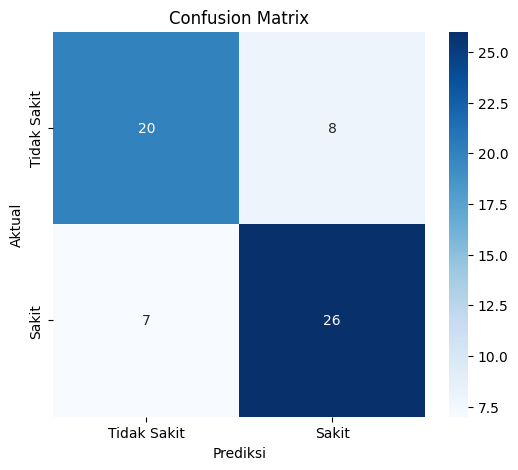

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Tidak Sakit", "Sakit"],
    yticklabels=["Tidak Sakit", "Sakit"]
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()

### Interpretasi

Confusion Matrix menunjukkan jumlah prediksi yang benar (True Positive dan True Negative) serta prediksi yang salah (False Positive dan False Negative).

Semakin banyak nilai pada diagonal utama, maka semakin baik performa model.

##D. Feature Importance

Random Forest mampu memberikan informasi mengenai tingkat kepentingan masing-masing fitur terhadap proses prediksi.

Visualisasi ini membantu mengetahui faktor kesehatan yang paling berpengaruh terhadap penyakit jantung.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,cp,0.173969
7,thalach,0.131634
11,ca,0.105700
9,oldpeak,0.096577
12,thal,0.090418
0,age,0.083049
8,exang,0.073679
3,trestbps,0.072088
4,chol,0.067384
1,sex,0.040229


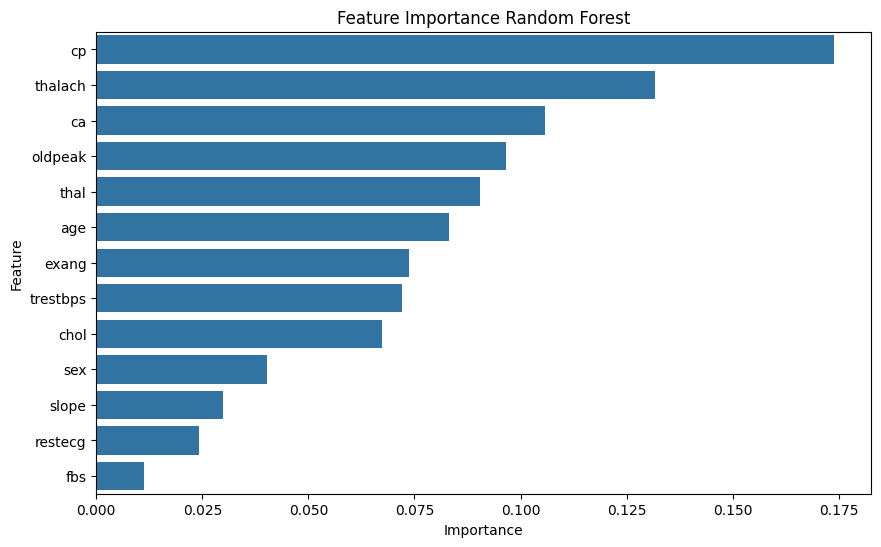

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance Random Forest")
plt.show()

### Interpretasi

Grafik Feature Importance menunjukkan fitur-fitur yang paling berpengaruh terhadap prediksi penyakit jantung.

Fitur dengan nilai importance tertinggi memiliki kontribusi yang lebih besar dalam proses pengambilan keputusan model Random Forest.

# **8. Implementasi Unsupervised Learning**

Pada tahap ini dilakukan proses **Unsupervised Learning** menggunakan algoritma **K-Means Clustering**.

Berbeda dengan Supervised Learning, proses clustering tidak menggunakan variabel target. Tujuannya adalah mengelompokkan pasien berdasarkan karakteristik kesehatan yang memiliki kemiripan sehingga dapat ditemukan pola alami pada data.

Dataset yang digunakan merupakan hasil preprocessing yang telah distandardisasi.

##A. Menentukan Jumlah Cluster

Sebelum membangun model K-Means, perlu ditentukan jumlah cluster yang paling optimal.

Pada penelitian ini digunakan **Elbow Method**, yaitu metode yang melihat nilai **Within Cluster Sum of Squares (WCSS)** untuk berbagai jumlah cluster.

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster)

    wcss.append(kmeans.inertia_)

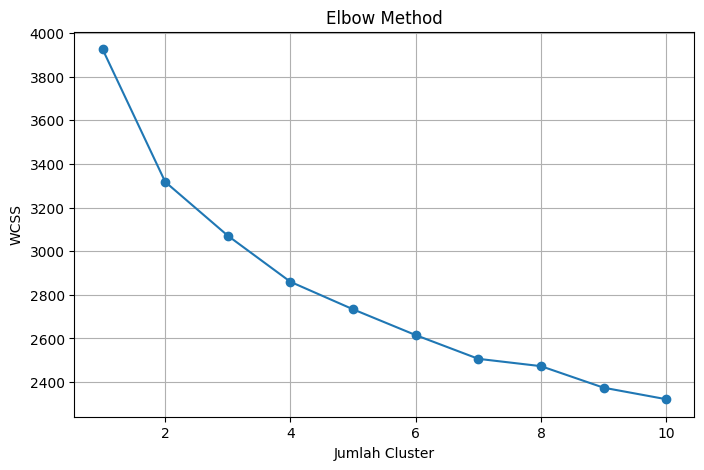

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Jumlah Cluster")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

### Interpretasi

Grafik Elbow Method digunakan untuk menentukan jumlah cluster yang optimal.

Titik siku (elbow) menunjukkan jumlah cluster terbaik karena setelah titik tersebut penurunan nilai WCSS menjadi lebih kecil.

Berdasarkan grafik, jumlah cluster yang dipilih adalah **3 cluster**.

##B. Membangun Model K-Means

Setelah jumlah cluster ditentukan, model K-Means dibangun untuk mengelompokkan pasien berdasarkan kemiripan karakteristik kesehatannya.

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster = kmeans.fit_predict(X_cluster)

cluster

array([0, 1, 2, 0, 1, 2, 2, 2, 0, 2, 2, 1, 0, 2, 1, 0, 2, 0, 1, 0, 0, 2,
       0, 0, 2, 0, 1, 1, 2, 2, 2, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 1, 0, 1, 2, 0, 2, 2, 2,
       1, 0, 1, 0, 1, 2, 0, 0, 0, 0, 2, 2, 1, 0, 0, 1, 0, 0, 2, 0, 2, 0,
       1, 0, 0, 2, 0, 2, 0, 2, 0, 2, 2, 1, 2, 2, 0, 2, 1, 2, 0, 0, 0, 0,
       0, 1, 0, 0, 2, 2, 2, 0, 0, 2, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 2, 0,
       0, 2, 0, 0, 0, 0, 2, 0, 0, 2, 1, 2, 2, 2, 2, 0, 0, 1, 2, 0, 0, 1,
       2, 0, 0, 0, 2, 0, 0, 1, 2, 0, 2, 2, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0,
       2, 1, 1, 0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 2, 1, 2, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 2, 2, 2, 2, 2,
       0, 0, 2, 0, 2, 0, 1, 1, 2, 2, 0, 1, 0, 2, 1, 0, 0, 2, 0, 0, 2, 0,
       2, 2, 2, 0, 1, 0, 1, 0, 0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 2, 0, 2, 0,
       0, 2, 0, 0, 0, 2, 0, 2, 2, 0, 0, 0, 0, 1, 0, 1, 1, 0, 2, 0, 2, 2,
       0, 0, 1, 2, 0, 2, 0, 0, 1, 1, 0, 2, 0, 0, 0,

In [ ]:
df_cluster = df.copy()

df_cluster["Cluster"] = cluster

df_cluster.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Cluster
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,1
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,2
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,1


### Interpretasi

Model K-Means berhasil mengelompokkan setiap pasien ke dalam salah satu cluster berdasarkan karakteristik kesehatannya.

Label cluster bukan menunjukkan tingkat keparahan penyakit, tetapi hanya sebagai penanda kelompok pasien yang memiliki kemiripan pola data.

##C. Visualisasi Cluster

Untuk mempermudah visualisasi hasil clustering, digunakan metode **Principal Component Analysis (PCA)**.

PCA mengurangi jumlah dimensi data menjadi dua komponen utama sehingga hasil clustering dapat divisualisasikan dalam bentuk scatter plot.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_cluster)

principal_df = pd.DataFrame(
    principal_components,
    columns=["PC1","PC2"]
)

principal_df["Cluster"] = cluster

principal_df.head()

,PC1,PC2,Cluster
0,-0.403727,-1.152038,0
1,2.614955,-0.600532,1
2,3.110398,-1.303946,2
3,-0.392439,-0.322416,0
4,2.255588,1.971414,1


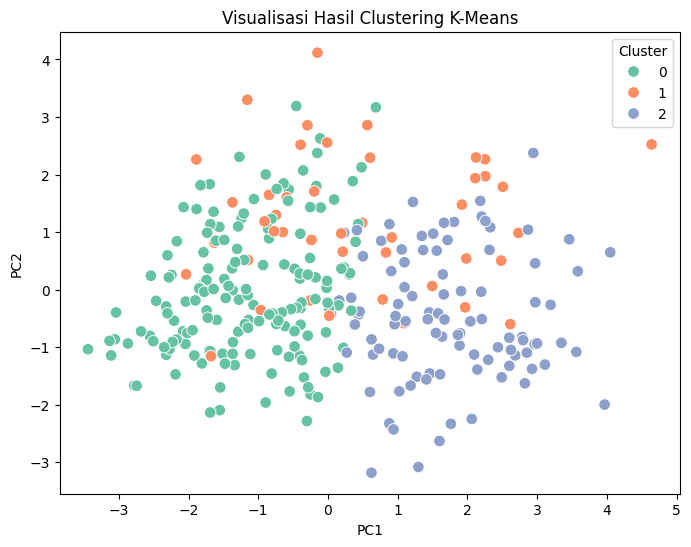

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=principal_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=70
)

plt.title("Visualisasi Hasil Clustering K-Means")

plt.show()

### Interpretasi

Visualisasi menunjukkan penyebaran data pasien ke dalam beberapa cluster.

Setiap warna mewakili kelompok pasien dengan karakteristik kesehatan yang serupa. Pemisahan cluster yang cukup jelas menunjukkan bahwa algoritma K-Means berhasil menemukan pola pada dataset.

# **9. Evaluasi Clustering**

Setelah proses clustering selesai dilakukan, tahap selanjutnya adalah mengevaluasi kualitas hasil pengelompokan.

Berbeda dengan Supervised Learning yang menggunakan label sebenarnya, evaluasi pada Unsupervised Learning dilakukan menggunakan metrik khusus yang mengukur kualitas pembentukan cluster.

Pada penelitian ini digunakan beberapa metode evaluasi, yaitu:

- Silhouette Score
- Davies-Bouldin Index
- Distribusi jumlah data pada setiap cluster
- Karakteristik masing-masing cluster

##A. Silhouette Score

Silhouette Score digunakan untuk mengukur seberapa baik setiap data berada pada clusternya sendiri dibandingkan dengan cluster lainnya.

Nilai Silhouette Score berada pada rentang -1 hingga 1.

- Semakin mendekati **1**, maka kualitas clustering semakin baik.
- Nilai mendekati **0** menunjukkan antar cluster saling tumpang tindih.
- Nilai negatif menunjukkan banyak data berada pada cluster yang kurang tepat.

In [ ]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(X_cluster, cluster)

print("Silhouette Score :", round(silhouette,3))

Silhouette Score : 0.165


### Interpretasi

Nilai Silhouette Score menunjukkan tingkat kualitas hasil clustering.

Semakin tinggi nilai yang diperoleh, maka semakin baik pemisahan antar cluster yang berhasil dibentuk oleh algoritma K-Means.

##B. Davies-Bouldin Index

Davies-Bouldin Index (DBI) digunakan untuk mengukur tingkat kemiripan antar cluster.

Berbeda dengan Silhouette Score, pada metrik ini nilai yang **lebih kecil** menunjukkan kualitas clustering yang lebih baik.

In [ ]:
from sklearn.metrics import davies_bouldin_score

dbi = davies_bouldin_score(X_cluster, cluster)

print("Davies-Bouldin Index :", round(dbi,3))

Davies-Bouldin Index : 2.044


### Interpretasi

Nilai Davies-Bouldin Index menunjukkan seberapa baik setiap cluster terpisah satu sama lain.

Semakin kecil nilai DBI, maka kualitas cluster semakin baik karena jarak antar cluster semakin besar dan variasi dalam cluster semakin kecil.

##C. Distribusi Data Tiap Cluster

Distribusi cluster digunakan untuk mengetahui jumlah pasien yang berada pada masing-masing cluster hasil pengelompokan.

In [ ]:
cluster_count = df_cluster["Cluster"].value_counts().sort_index()

cluster_count

,count
Cluster,
0,163
1,44
2,95


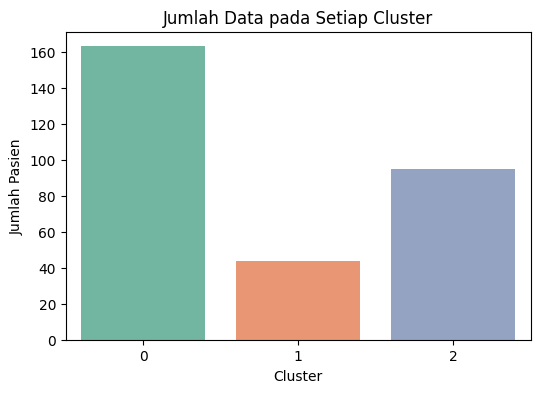

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_cluster,
    x="Cluster",
    palette="Set2"
)

plt.title("Jumlah Data pada Setiap Cluster")

plt.xlabel("Cluster")

plt.ylabel("Jumlah Pasien")

plt.show()

### Interpretasi

Visualisasi menunjukkan jumlah anggota pada masing-masing cluster.

Distribusi ini memberikan gambaran apakah hasil clustering menghasilkan kelompok yang relatif seimbang atau terdapat cluster yang jauh lebih dominan.

##D. Karakteristik Tiap Cluster

Untuk memahami karakteristik masing-masing cluster, dilakukan perhitungan nilai rata-rata setiap fitur berdasarkan cluster.

Analisis ini membantu mengidentifikasi ciri khas dari setiap kelompok pasien.

In [ ]:
cluster_summary = df_cluster.groupby("Cluster").mean()

cluster_summary.round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
Cluster,,,,,,,,,,,,,,
0,51.18,0.63,1.23,128.99,244.64,0.00,0.58,161.70,0.11,0.54,1.67,0.36,2.20,0.76
1,57.02,0.73,1.23,139.27,247.11,1.00,0.43,150.23,0.34,1.04,1.34,1.09,2.25,0.52
2,58.78,0.75,0.38,132.54,249.41,0.01,0.48,128.45,0.69,1.91,0.96,1.17,2.54,0.18


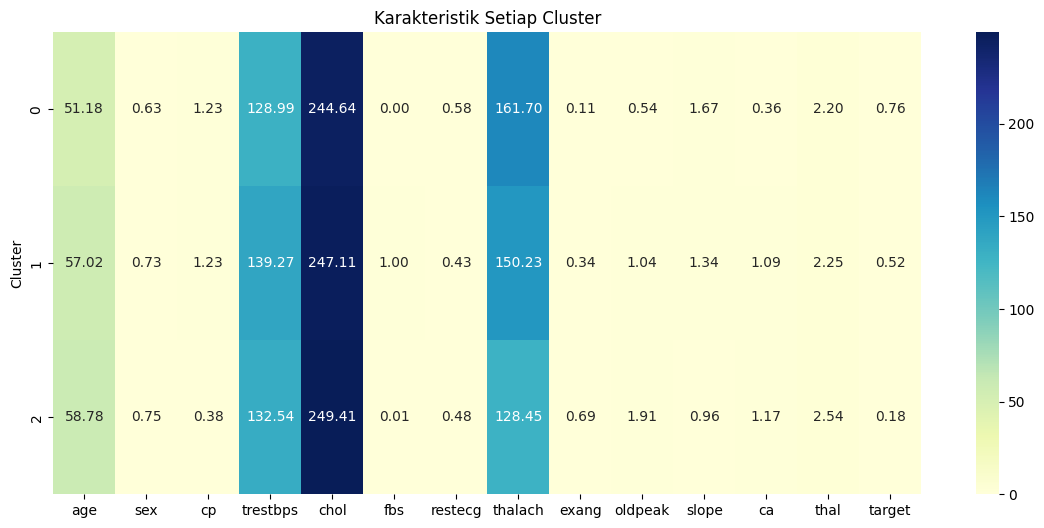

In [ ]:
plt.figure(figsize=(14,6))

sns.heatmap(
    cluster_summary,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Karakteristik Setiap Cluster")

plt.show()

### Interpretasi

Heatmap menunjukkan rata-rata nilai setiap fitur pada masing-masing cluster.

Perbedaan nilai rata-rata antar cluster menunjukkan bahwa algoritma K-Means berhasil mengelompokkan pasien berdasarkan karakteristik kesehatan yang berbeda.

Analisis ini dapat digunakan untuk mengidentifikasi kelompok pasien yang memiliki risiko kesehatan tertentu.

# **10. Implementasi Gradio**

Pada tahap ini dibuat antarmuka sederhana menggunakan **Gradio** untuk memudahkan pengguna melakukan prediksi penyakit jantung.

Pengguna cukup memasukkan data kesehatan pasien, kemudian model Random Forest akan memberikan hasil prediksi apakah pasien berpotensi mengalami penyakit jantung atau tidak.

##A. Menyimpan Model

Model yang telah dilatih disimpan menggunakan library **Joblib** agar dapat digunakan kembali tanpa perlu melakukan proses pelatihan ulang.

In [ ]:
import joblib

# Menyimpan model
joblib.dump(model, "heart_disease_model.pkl")

# Menyimpan scaler
joblib.dump(scaler, "scaler.pkl")

print("Model dan scaler berhasil disimpan.")

Model dan scaler berhasil disimpan.


##B. Import Library Gradio

Library Gradio digunakan untuk membuat antarmuka web sederhana sehingga model Machine Learning dapat digunakan secara interaktif.

In [ ]:
!pip install gradio -q

import gradio as gr

##C. Membuat Fungsi Prediksi

Fungsi prediksi menerima data masukan dari pengguna, melakukan proses standardisasi menggunakan scaler yang telah disimpan, kemudian menghasilkan prediksi menggunakan model Random Forest.

In [ ]:
def predict_heart_disease(
    age,
    sex,
    cp,
    trestbps,
    chol,
    fbs,
    restecg,
    thalach,
    exang,
    oldpeak,
    slope,
    ca,
    thal
):

    data = pd.DataFrame([[

        age,
        sex,
        cp,
        trestbps,
        chol,
        fbs,
        restecg,
        thalach,
        exang,
        oldpeak,
        slope,
        ca,
        thal

    ]], columns=X.columns)

    data_scaled = scaler.transform(data)

    prediction = model.predict(data_scaled)[0]

    if prediction == 1:
        return "Berpotensi Mengalami Penyakit Jantung"
    else:
        return "Tidak Berpotensi Mengalami Penyakit Jantung"

##D.Membuat Interface

Interface dibuat menggunakan komponen input berupa angka sesuai dengan fitur pada dataset. Hasil prediksi akan ditampilkan dalam bentuk teks.

In [ ]:
interface = gr.Interface(

    fn=predict_heart_disease,

    inputs=[

        gr.Number(label="Age (Years)"),

        gr.Number(label="Sex (1 = Male, 0 = Female)"),

        gr.Number(label="Chest Pain Type (0 = Typical Angina, 1 = Atypical Angina, 2 = Non-anginal Pain, 3 = Asymptomatic)"),

        gr.Number(label="Resting Blood Pressure (mmHg)"),

        gr.Number(label="Cholesterol (mg/dL)"),

        gr.Number(label="Fasting Blood Sugar (1 = >120 mg/dL, 0 = ≤120 mg/dL)"),

        gr.Number(label="Resting ECG (0 = Normal, 1 = ST-T Wave Abnormality, 2 = Left Ventricular Hypertrophy)"),

        gr.Number(label="Maximum Heart Rate Achieved"),

        gr.Number(label="Exercise Induced Angina (1 = Yes, 0 = No)"),

        gr.Number(label="Oldpeak (ST Depression)"),

        gr.Number(label="Slope (0 = Upsloping, 1 = Flat, 2 = Downsloping)"),

        gr.Number(label="CA (Number of Major Vessels: 0–4)"),

        gr.Number(label="Thal (1 = Normal, 2 = Fixed Defect, 3 = Reversible Defect)")

    ],

    outputs=gr.Textbox(label="Prediction Result"),

    title="Heart Disease Prediction",

    description="""
Enter the patient's medical information below.
The Random Forest model will predict whether the patient is likely to have heart disease.
"""

)

##E. Menjalankan Aplikasi

Aplikasi Gradio dijalankan sehingga pengguna dapat mencoba melakukan prediksi secara langsung melalui browser.

In [1]:
interface.launch(share=True)

NameError: name 'interface' is not defined

### Interpretasi

Antarmuka Gradio berhasil dibuat dan dapat digunakan untuk melakukan prediksi penyakit jantung secara interaktif.

Pengguna hanya perlu memasukkan nilai setiap fitur kesehatan, kemudian sistem akan memberikan hasil prediksi berdasarkan model Random Forest yang telah dilatih sebelumnya.

# **11. Insight dan Kesimpulan**

Berdasarkan hasil implementasi dan evaluasi yang telah dilakukan, proyek ini berhasil menerapkan dua pendekatan Machine Learning menggunakan dataset **Heart Disease Prediction**, yaitu **Supervised Learning** dan **Unsupervised Learning**.

Pada pendekatan **Supervised Learning**, algoritma **Random Forest Classifier** berhasil digunakan untuk memprediksi kemungkinan penyakit jantung berdasarkan data kesehatan pasien. Hasil evaluasi menunjukkan bahwa model memiliki performa yang baik dalam melakukan klasifikasi, sehingga dapat dimanfaatkan sebagai alat bantu dalam proses prediksi penyakit jantung.

Pada pendekatan **Unsupervised Learning**, algoritma **K-Means Clustering** berhasil mengelompokkan pasien berdasarkan karakteristik kesehatan yang dimiliki tanpa menggunakan label target. Hasil clustering menunjukkan adanya beberapa kelompok pasien dengan karakteristik yang berbeda, sehingga dapat digunakan sebagai dasar dalam analisis segmentasi pasien.

Selain itu, implementasi model menggunakan **Gradio** berhasil menghasilkan aplikasi sederhana yang memungkinkan pengguna melakukan prediksi penyakit jantung secara interaktif melalui antarmuka web. Hal ini menunjukkan bahwa model Machine Learning tidak hanya dapat dibangun dan dievaluasi, tetapi juga dapat diimplementasikan dalam bentuk aplikasi yang mudah digunakan.

Secara keseluruhan, proyek ini menunjukkan bahwa satu dataset dapat dimanfaatkan untuk dua tujuan yang berbeda namun saling melengkapi. **Supervised Learning** berfokus pada prediksi status penyakit jantung berdasarkan data pasien, sedangkan **Unsupervised Learning** berfokus pada pengelompokan pasien berdasarkan kemiripan karakteristik kesehatannya. Kombinasi kedua pendekatan tersebut memberikan pemahaman yang lebih komprehensif terhadap data, baik dari sisi prediksi maupun analisis pola.

Ke depannya, penelitian ini dapat dikembangkan dengan menggunakan dataset yang lebih besar, membandingkan performa beberapa algoritma klasifikasi dan clustering, serta mengembangkan aplikasi menjadi sistem berbasis web yang lebih lengkap sehingga dapat memberikan manfaat yang lebih luas dalam mendukung pengambilan keputusan di bidang kesehatan.